# Feed-forward classifier on MNIST digits

Train a fully-connected network with batch normalization and dropout on scikit-learn's
handwritten digits, then evaluate it with a confusion matrix.

In [1]:
import pytensor

floatX = "float32"
pytensor.config.floatX = floatX

In [2]:
import numpy as np

from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

from pytensor_ml.activations import LeakyReLU
from pytensor_ml.layers import BatchNorm, Dropout, Input, Linear, Sequential
from pytensor_ml.loss import CrossEntropy
from pytensor_ml.model import Model
from pytensor_ml.optim import adagrad
from pytensor_ml.util import DataLoader

In [3]:
X, y = load_digits(return_X_y=True)
y_onehot = OneHotEncoder().fit_transform(y[:, None]).toarray().astype(floatX)
X_normed = MinMaxScaler().fit_transform(X).astype(floatX)

In [4]:
X_in = Input("X_in", shape=(None, 64))

In [5]:
prediction_network = Sequential(
    Linear("Linear_1", n_in=64, n_out=256),
    BatchNorm("BatchNorm_1"),
    Dropout("Dropout_1", p=0.5),
    LeakyReLU(),
    Linear("Linear_2", n_in=256, n_out=128),
    BatchNorm("BatchNorm_2"),
    Dropout("Dropout_2", p=0.5),
    LeakyReLU(),
    Linear("Logits", n_in=128, n_out=10),
)

y_hat = prediction_network(X_in)
model = Model(y_hat, compile_kwargs={"mode": "NUMBA"})
model

In [6]:
loss_fn = CrossEntropy(expect_onehot_labels=True, expect_logits=True, reduction="mean")

In [7]:
# `model.compile_train` is the training companion to `model.predict`: it builds the loss against a target,
# differentiates it, folds in the BatchNorm running-statistic updates, and compiles a one-step training
# function (reusing the model's NUMBA compile settings).
step = model.compile_train(adagrad(learning_rate=1e-3), loss_fn)

In [8]:
model.initialize()

In [9]:
from tqdm.notebook import tqdm

loader = DataLoader(X_normed, y_onehot)
loss_history = []
n_epochs = 10_000

for _ in tqdm(range(n_epochs)):
    X_batch, y_batch = loader()
    loss_value = step(X_batch, y_batch)
    loss_history.append(loss_value)

  0%|          | 0/10000 [00:00<?, ?it/s]

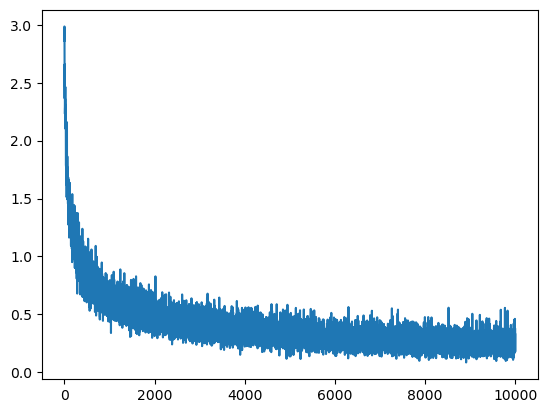

In [10]:
import matplotlib.pyplot as plt

plt.plot(loss_history)

In [11]:
from scipy.special import softmax

# `model.predict` compiles a forward pass specialized for inference: Dropout is dropped and BatchNorm uses its
# running statistics.
y_hat_logits = model.predict(X_normed)
y_hat_probs = softmax(y_hat_logits, axis=-1)
y_pred = np.argmax(y_hat_probs, axis=-1)

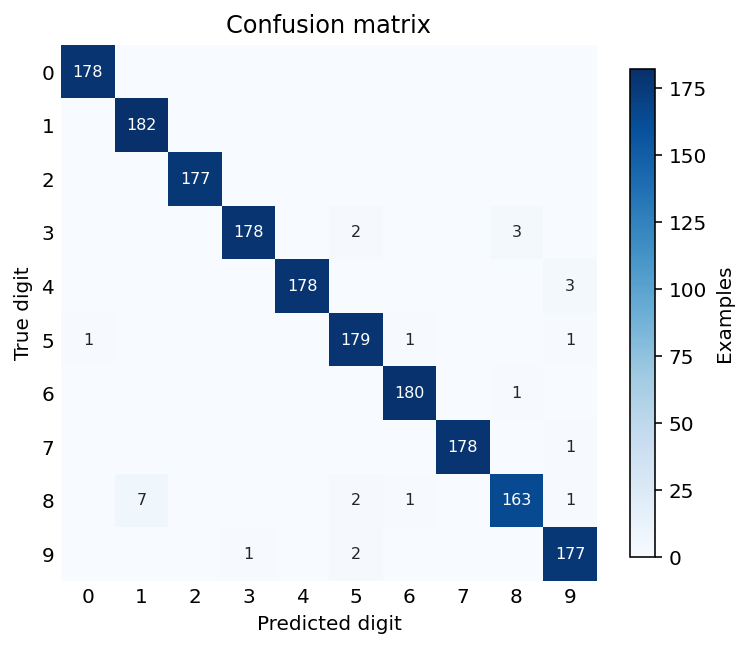

In [12]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

counts = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(6, 5.5), dpi=144)
image = ax.imshow(counts, cmap="Blues")

# White reads on the dark end of the ramp, ink on the light end.
dark_cell_floor = counts.max() / 2

for (true_digit, predicted_digit), count in np.ndenumerate(counts):
    if count:
        text_color = "white" if count > dark_cell_floor else "0.15"
        ax.text(
            predicted_digit,
            true_digit,
            count,
            ha="center",
            va="center",
            color=text_color,
            fontsize=8,
        )

ax.set(xlabel="Predicted digit", ylabel="True digit", title="Confusion matrix")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(image, ax=ax, shrink=0.8, label="Examples")
plt.show()